In [4]:
# --- Cell 1: imports + config ---
%load_ext autoreload
%autoreload 2
import sys, torch, numpy as np
sys.path.append('..')
sys.path.append('../..')

from common.seed import set_seed
from common.io_utils import save_results, load_results
from task4.img_prep.cifar_data import build_known_loaders
from task4.backbones.resnet_cifar import CifarResNet18
from task4.training.train_loop import train_model
from task4.methods.vanilla import Vanilla
from task4.evaluations.metrics import extract_outputs, accuracy, macro_f1, per_class_accuracy

set_seed(6304)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DATA_ROOT = '../../datasets'
splits = load_results('../../shared/splits/cifar10_seed6304.json')

CFG = dict(seed=6304, num_classes=10, batch_size=128, eval_batch=512, num_workers=0,
           epochs=100, lr=0.1, momentum=0.9, weight_decay=5e-4,
           schedule='cosine', randaugment=False, amp=False)
print(device, torch.cuda.get_device_name(0) if device.type == 'cuda' else '')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
cuda NVIDIA GeForce RTX 4060 Laptop GPU


In [5]:
# --- Cell 2: VERIFICATION — init loss, BN behaviour, gradient flow, schedule ---

import torch.nn.functional as F
probe_loaders = build_known_loaders(DATA_ROOT, splits, batch_size=CFG['batch_size'],
                                    eval_batch=CFG['eval_batch'], num_workers=0,
                                    seed=CFG['seed'], randaugment=False)
set_seed(6304)
probe = CifarResNet18(num_classes=10).to(device)
xb, yb = next(iter(probe_loaders['train']))
xb, yb = xb.to(device), yb.to(device)

bn = [m for m in probe.modules() if isinstance(m, torch.nn.BatchNorm2d)]
before = bn[0].running_mean.clone()      # clone BEFORE any forward pass:
probe.train()                            # BN updates running stats in FORWARD,
logits, _ = probe(xb)                    # not in backward
after_fwd = bn[0].running_mean.clone()
loss0 = F.cross_entropy(logits, yb)
loss0.backward()

print(f'initial loss          : {loss0.item():.4f}   (expect ~2.30-2.40)')
print('labels in range 0-9   :', int(yb.min()) >= 0 and int(yb.max()) <= 9)
print('BN modules            :', len(bn), '| in TRAIN mode:', all(m.training for m in bn))
print('BN stats update (fwd) :', not torch.allclose(before, after_fwd))
print('grad reaches conv1    :', probe.net.conv1.weight.grad.abs().sum().item() > 0)
print(f'feature std at init   : {probe(xb)[1].std().item():.3f}')

opt = torch.optim.SGD(probe.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4)
s = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=100)
lrs = []
for _ in range(100):
    lrs.append(opt.param_groups[0]['lr'])
    opt.step(); s.step()                 # step optimizer first: silences the
                                         # ordering warning, schedule unchanged
print(f'lr at ep 1/50/100     : {lrs[0]:.5f} {lrs[49]:.5f} {lrs[99]:.6f}')
del probe, probe_loaders, xb, yb, logits, loss0, opt, s
torch.cuda.empty_cache()

initial loss          : 2.3522   (expect ~2.30-2.40)
labels in range 0-9   : True
BN modules            : 20 | in TRAIN mode: True
BN stats update (fwd) : True
grad reaches conv1    : True
feature std at init   : 0.341
lr at ep 1/50/100     : 0.10000 0.05157 0.000025


In [6]:
# --- Cell 3: train Vanilla ---
set_seed(6304)
loaders = build_known_loaders(DATA_ROOT, splits, batch_size=CFG['batch_size'],
                              eval_batch=CFG['eval_batch'], num_workers=CFG['num_workers'],
                              seed=CFG['seed'], randaugment=CFG['randaugment'])
model = CifarResNet18(num_classes=CFG['num_classes']).to(device)
method = Vanilla(CFG).to(device)
out = train_model(model, method, loaders, CFG, device,
                  ckpt_path='../../datasets/cache/task4_vanilla.pt')
print(f"best epoch {out['best_epoch']}  val_acc {out['best_val_acc']:.4f}  {out['minutes']:.1f} min")

ep001 lr=0.1000 loss_cls=1.9157 train_acc=0.3107 | val_acc=0.4322 | best=0.4322@1 | 0.7m
ep002 lr=0.1000 loss_cls=1.3861 train_acc=0.4915 | val_acc=0.5480 | best=0.5480@2 | 1.4m
ep003 lr=0.0999 loss_cls=1.1166 train_acc=0.6004 | val_acc=0.6170 | best=0.6170@3 | 2.1m
ep005 lr=0.0996 loss_cls=0.7553 train_acc=0.7351 | val_acc=0.7544 | best=0.7544@5 | 3.6m
ep010 lr=0.0980 loss_cls=0.4915 train_acc=0.8328 | val_acc=0.8134 | best=0.8134@10 | 7.2m
ep015 lr=0.0952 loss_cls=0.4163 train_acc=0.8563 | val_acc=0.8340 | best=0.8340@15 | 10.8m
ep020 lr=0.0914 loss_cls=0.3771 train_acc=0.8709 | val_acc=0.8048 | best=0.8472@19 | 14.4m
ep025 lr=0.0864 loss_cls=0.3415 train_acc=0.8835 | val_acc=0.8494 | best=0.8494@25 | 18.1m
ep030 lr=0.0806 loss_cls=0.3155 train_acc=0.8920 | val_acc=0.8734 | best=0.8734@30 | 21.7m
ep035 lr=0.0741 loss_cls=0.2846 train_acc=0.9034 | val_acc=0.8640 | best=0.8734@30 | 25.3m
ep040 lr=0.0669 loss_cls=0.2624 train_acc=0.9101 | val_acc=0.8446 | best=0.8734@30 | 29.0m
ep045 lr

In [7]:
# --- Cell 4: freeze 
cache = {}
for split in ['train_eval', 'val', 'test']:
    o = extract_outputs(model, loaders[split], device, keep_features=True)
    cache[f'{split}_logits'] = o['logits']
    cache[f'{split}_features'] = o['features']
    cache[f'{split}_labels'] = o['labels']
    print(f"{split:11s} logits {o['logits'].shape}  features {o['features'].shape}")

from pathlib import Path
Path('../../datasets/cache').mkdir(parents=True, exist_ok=True)
np.savez_compressed('../../datasets/cache/task4_vanilla_known.npz', **cache)

csa = accuracy(cache['test_logits'], cache['test_labels'])
print(f"\nCIFAR-10 TEST accuracy (CSA) : {csa:.4f}")
print(f"CIFAR-10 test macro-F1       : {macro_f1(cache['test_logits'], cache['test_labels']):.4f}")
print(f"val accuracy (checkpointed)  : {accuracy(cache['val_logits'], cache['val_labels']):.4f}")
pc = per_class_accuracy(cache['test_logits'], cache['test_labels'])
for c, name in enumerate(splits['classes']):
    print(f"  {name:12s} {pc[c]:.4f}")

train_eval  logits (45000, 10)  features (45000, 512)
val         logits (5000, 10)  features (5000, 512)
test        logits (10000, 10)  features (10000, 512)

CIFAR-10 TEST accuracy (CSA) : 0.9461
CIFAR-10 test macro-F1       : 0.9460
val accuracy (checkpointed)  : 0.9502
  airplane     0.9540
  automobile   0.9720
  bird         0.9200
  cat          0.8710
  deer         0.9560
  dog          0.9220
  frog         0.9670
  horse        0.9650
  ship         0.9680
  truck        0.9660


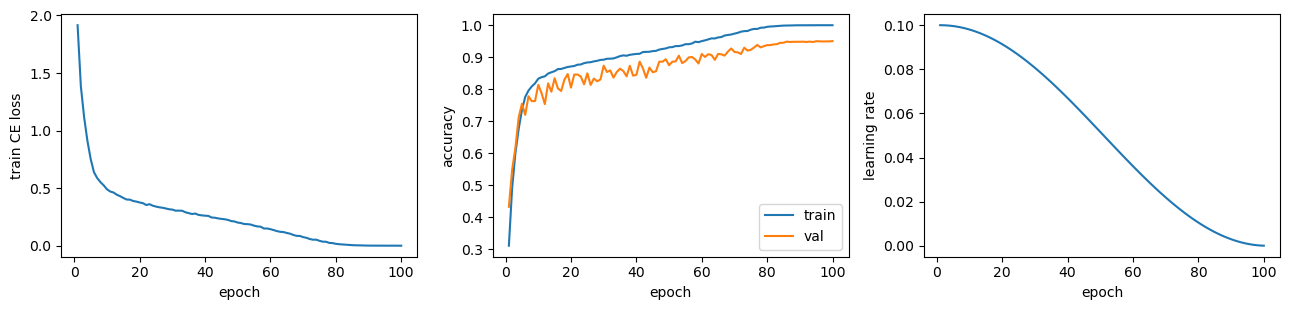

In [8]:
# --- Cell 5: save results + training curves ---
results = {'step': 'vanilla', 'seed': 6304, 'method': 'vanilla', 'config': CFG,
           'steps_per_epoch': loaders['steps_per_epoch'],
           'best_epoch': out['best_epoch'], 'best_val_acc': out['best_val_acc'],
           'test_accuracy': csa,
           'test_macro_f1': macro_f1(cache['test_logits'], cache['test_labels']),
           'per_class_test_accuracy': {n: float(pc[i]) for i, n in enumerate(splits['classes'])},
           'minutes': out['minutes'], 'history': out['history'],
           'cache_file': 'datasets/cache/task4_vanilla_known.npz'}
save_results(results, '../results/vanilla.json')

import matplotlib.pyplot as plt
h = out['history']; ep = [r['epoch'] for r in h]
fig, ax = plt.subplots(1, 3, figsize=(13, 3.2))
ax[0].plot(ep, [r['loss_cls'] for r in h]); ax[0].set_xlabel('epoch'); ax[0].set_ylabel('train CE loss')
ax[1].plot(ep, [r['train_acc'] for r in h], label='train')
ax[1].plot(ep, [r['val_acc'] for r in h], label='val')
ax[1].set_xlabel('epoch'); ax[1].set_ylabel('accuracy'); ax[1].legend()
ax[2].plot(ep, [r['lr'] for r in h]); ax[2].set_xlabel('epoch'); ax[2].set_ylabel('learning rate')
plt.tight_layout(); plt.savefig('../../report/figures/task4_vanilla_curves.png', dpi=200)
plt.show()